In [67]:
import sys; print(sys.executable)

/Users/tomrodger/ml-foundations/.venv/bin/python


In [68]:
from engine import Value
from nn import MLP
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [69]:
# Generating samples and defining graph function 

X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1

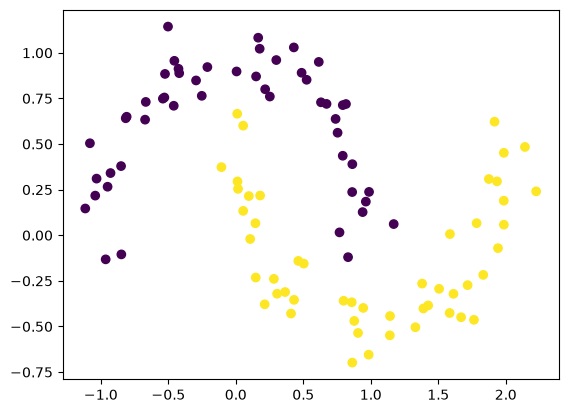

In [70]:
# Plotting the function
plt.scatter(X[:,0], X[:,1], c=y)

In [71]:
# Create neural network
n = MLP(2, [16, 16, 16, 1]) # 2 inputs, 2 hidden layers, 1 ouput, 337 parameters

In [72]:
# Training Loop
steps = 200
inputs = [list(map(Value, xrow))for xrow in X]

for k in range(steps):
    scores = [n(xi) for xi in inputs]
    loss = sum((si - yi)**2 for si, yi in zip(scores, y)) * (1.0 / len(scores))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()


    lr = 0.02

    for p in n.parameters():
        p.data -= lr * p.grad
    
    print(k, loss.data)

# 500 steps on 3 hidden layers took 8m 2.6s


0 4.613004347819718
1 23.10389016154692
2 9.366451945739199
3 1.4440038434614513
4 0.903451878962669
5 0.6818615587712671
6 0.584294337373057
7 0.5240527237863121
8 0.48043578033074374
9 0.4460571905501411
10 0.4228171104683602
11 0.4051112635240465
12 0.38981431299173586
13 0.3769518494435598
14 0.36673716067535517
15 0.3586752845928109
16 0.35190077547687815
17 0.34575647525267805
18 0.340213696373718
19 0.3350554846465933
20 0.3299493861871616
21 0.32466206140215886
22 0.31974658922641136
23 0.3151218688564341
24 0.31075850347990797
25 0.30662355282957166
26 0.3027152490211459
27 0.2989108795209066
28 0.2952472501399669
29 0.29189368588664616
30 0.2887248213275587
31 0.2857770281551857
32 0.2830823305511606
33 0.2804677003896584
34 0.27794052841692657
35 0.27546863435969166
36 0.2730362517725662
37 0.2706702493556876
38 0.26834042367001154
39 0.2660662605122576
40 0.26379998273000005
41 0.26157471041952846
42 0.25934369550345265
43 0.25711103606577534
44 0.2549086552425066
45 0.2527

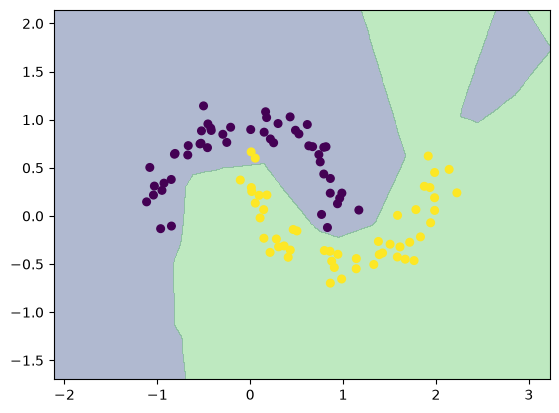

In [73]:
# Decision boundary
h = 0.02
xx, yy = np.meshgrid(np.arange(X[:,0].min()-1, X[:,0].max()+1, h),
                     np.arange(X[:,1].min()-1, X[:,1].max()+1, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([n(list(map(Value, pt))).data > 0 for pt in grid]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y, s=30)